In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Loading and Preprocessing

In [8]:
#Load dataset
data = load_breast_cancer()
#print(data.feature_names)
#print(data.DESCR)
print(data.data.shape)

(569, 30)


In [9]:
#Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign

print(df.head())
print(df.shape)
print(df['target'].value_counts())
print(data.target_names)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [11]:
#Check missing values
print(df.isnull().sum().sum())

0


In [12]:
#Split features and target
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler: features have different scales (radius, texture, area, etc.). Important for Logistic Regression, SVM, k-NN. Tree models don’t need scaling, but scaling all keeps comparison consistent

Classification Algorithm Implementation

In [14]:
#helper function
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    return {"Model": name, "Accuracy": acc}

In [15]:
#Logistic Regression
results = []
results.append(evaluate_model(
    LogisticRegression(max_iter=1000),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression"
))


Logistic Regression
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



 Uses a sigmoid function to predict class probability (malignant/benign). Good baseline for binary medical classification, works well with scaled features.

In [16]:
#Decision Tree Classifier
results.append(evaluate_model(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Decision Tree Classifier"
))


Decision Tree Classifier
Accuracy: 0.9122807017543859
Confusion Matrix:
 [[39  3]
 [ 7 65]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



Splits data using feature thresholds into pure classes. Easy to interpret, can overfit if the tree is too deep.

Random Forest Classifier

In [17]:
results.append(evaluate_model(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Random Forest Classifier"
))


Random Forest Classifier
Accuracy: 0.956140350877193
Confusion Matrix:
 [[39  3]
 [ 2 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Many decision trees combined by voting. More accurate and stable than one tree, strong on tabular medical data.

In [18]:
#Support Vector Machine (SVM)
results.append(evaluate_model(
    SVC(kernel='rbf'),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Support Vector Machine"
))


Support Vector Machine
Accuracy: 0.9824561403508771
Confusion Matrix:
 [[41  1]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Finds the best separating boundary (hyperplane) between classes. Very suitable for this dataset, performs well after scaling.

k-Nearest Neighbors (k-NN)

In [19]:
results.append(evaluate_model(
    KNeighborsClassifier(n_neighbors=5),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "k-Nearest Neighbors"
))


k-Nearest Neighbors
Accuracy: 0.956140350877193
Confusion Matrix:
 [[39  3]
 [ 2 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Classifies a sample based on the majority class of its k nearest neighbors. Simple and effective, must use scaled features because it is distance-based.

Model Comparison

In [20]:
#Compare accuracies
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Accuracy', ascending=False))

                      Model  Accuracy
0       Logistic Regression  0.982456
3    Support Vector Machine  0.982456
2  Random Forest Classifier  0.956140
4       k-Nearest Neighbors  0.956140
1  Decision Tree Classifier  0.912281


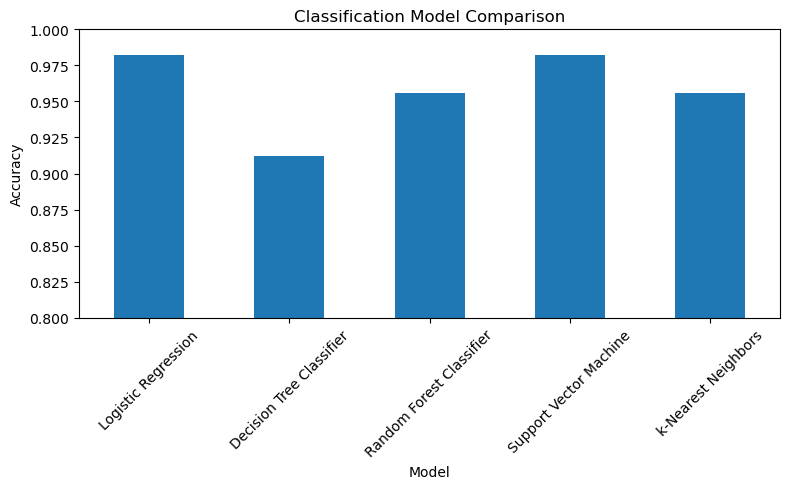

In [21]:
#Bar chart
results_df.plot(x='Model', y='Accuracy', kind='bar', legend=False, figsize=(8, 5))
plt.ylabel('Accuracy')
plt.title('Classification Model Comparison')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

Logistic Regression and SVM performed best (~98% accuracy), while Decision Tree performed worst (~91%). All models worked well after preprocessing and scaling.